# Notebook for the 1000 Runs Ensemble

In [1]:
import pandas as pd
import os
from utils.eda_utils import EDAUtils
import boto3

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
MAPPING_DIR_PATH = os.path.join(DATA_DIR_PATH, "mapping")
SSP_DIR_PATH = os.path.join(DATA_DIR_PATH, "ssp")
TRAINING_DIR_PATH = os.path.join(DATA_DIR_PATH, "training")
CONFIG_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "config")

In [4]:
os.makedirs(SSP_DIR_PATH, exist_ok=True)

In [5]:
edau = EDAUtils()

## Pull data from AWS S3


In [6]:
aws_config = edau.read_yaml(os.path.join(CONFIG_DIR_PATH, "aws_credentials_config.yaml"))
profile_name = aws_config["profile_name"]
bucket_name = aws_config["bucket_name"]
# Set your profile
session = boto3.Session(profile_name=profile_name)

# Create an S3 client or resource
s3 = session.resource('s3')

run_id = "sisepuede_run_2025-10-07t08;18;39.653077" #NOTE: Update this for each run

# Define folder prefix
prefix = f'transfers/{run_id}/'  # this is like the "folder" in S3

In [8]:
# Local destination
destination = os.path.join(SSP_DIR_PATH, run_id)
if os.path.exists(destination) and os.listdir(destination):
    print(f"Destination '{destination}' already exists and is not empty. Skipping download.")
else:
    os.makedirs(destination, exist_ok=True)
    bucket = s3.Bucket(bucket_name)
    for obj in bucket.objects.filter(Prefix=prefix):
        if obj.key.endswith('/') or "transformations" in obj.key:  # skip directories and transformations
            continue
        target_path = os.path.join(destination, os.path.basename(obj.key))
        print(f"Downloading {obj.key} to {target_path}")
        bucket.download_file(obj.key, target_path)

In [9]:
SIMULATION_DIR_PATH = os.path.join(SSP_DIR_PATH, run_id)
print(SIMULATION_DIR_PATH)

/Users/tony/Documents/sisepuede_modeling/ssp_uganda_data/metamodel/data/ssp/sisepuede_run_2025-10-07t08;18;39.653077


## Load and Process LHC Samples Dataframes

In [10]:
# Load lhc samples dfs
lhs_exogenous_df = pd.read_csv(os.path.join(SIMULATION_DIR_PATH, "ATTRIBUTE_LHC_SAMPLES_EXOGENOUS_UNCERTAINTIES.csv"))
lhs_levers_df = pd.read_csv(os.path.join(SIMULATION_DIR_PATH, "ATTRIBUTE_LHC_SAMPLES_LEVER_EFFECTS.csv"))

In [11]:
lhs_exogenous_df.head()

,region,design_id,future_id,60,61,62,63,64,65,66,67,68
0,uganda,-1,1,0.547746,0.784382,0.142538,0.798656,0.138570,0.461001,0.760845,0.677736,0.667778
1,uganda,-1,2,0.104242,0.871744,0.885693,0.731615,0.393896,0.254986,0.388944,0.079108,0.226586
2,uganda,-1,3,0.450676,0.745613,0.955297,0.108820,0.299103,0.962902,0.367651,0.181581,0.154460
3,uganda,-1,4,0.793911,0.915802,0.259297,0.303791,0.188833,0.473412,0.973142,0.756275,0.432518
4,uganda,-1,5,0.781801,0.126404,0.934463,0.344480,0.277149,0.441921,0.477712,0.973170,0.205513


In [12]:
lhs_levers_df.head()

,region,design_id,future_id,1,2,3,4,5,6,7,...,1715,1716,1718,1730,1731,1734,1735,1737,1739,1740
0,uganda,-1,1,0.604470,0.418041,0.096242,0.210880,0.205440,0.878380,0.598848,...,0.009016,0.593854,0.880245,0.309954,0.253500,0.406424,0.798275,0.452258,0.605287,0.026657
1,uganda,-1,2,0.222092,0.310322,0.558757,0.903304,0.453622,0.175245,0.908939,...,0.934020,0.610388,0.658542,0.620146,0.150415,0.055407,0.995960,0.052648,0.893614,0.608447
2,uganda,-1,3,0.817603,0.388984,0.048647,0.458366,0.023411,0.653164,0.514104,...,0.728165,0.798418,0.066505,0.718230,0.087879,0.123014,0.001255,0.693685,0.196415,0.197307
3,uganda,-1,4,0.446228,0.162661,0.748722,0.453093,0.676908,0.096409,0.772990,...,0.638554,0.546941,0.238074,0.363871,0.374376,0.468245,0.705076,0.048635,0.847648,0.282021
4,uganda,-1,5,0.757954,0.592749,0.227212,0.011940,0.765432,0.831340,0.361240,...,0.451593,0.602214,0.959041,0.671558,0.514413,0.191157,0.143267,0.914037,0.818161,0.733172


In [13]:
# Add suffix to lever columns to distinguish them later
lhs_levers_df = lhs_levers_df.add_suffix('_L')
lhs_levers_df = lhs_levers_df.rename(columns={"region_L": "region", "design_id_L": "design_id", "future_id_L": "future_id"})
lhs_levers_df.head()

,region,design_id,future_id,1_L,2_L,3_L,4_L,5_L,6_L,7_L,...,1715_L,1716_L,1718_L,1730_L,1731_L,1734_L,1735_L,1737_L,1739_L,1740_L
0,uganda,-1,1,0.604470,0.418041,0.096242,0.210880,0.205440,0.878380,0.598848,...,0.009016,0.593854,0.880245,0.309954,0.253500,0.406424,0.798275,0.452258,0.605287,0.026657
1,uganda,-1,2,0.222092,0.310322,0.558757,0.903304,0.453622,0.175245,0.908939,...,0.934020,0.610388,0.658542,0.620146,0.150415,0.055407,0.995960,0.052648,0.893614,0.608447
2,uganda,-1,3,0.817603,0.388984,0.048647,0.458366,0.023411,0.653164,0.514104,...,0.728165,0.798418,0.066505,0.718230,0.087879,0.123014,0.001255,0.693685,0.196415,0.197307
3,uganda,-1,4,0.446228,0.162661,0.748722,0.453093,0.676908,0.096409,0.772990,...,0.638554,0.546941,0.238074,0.363871,0.374376,0.468245,0.705076,0.048635,0.847648,0.282021
4,uganda,-1,5,0.757954,0.592749,0.227212,0.011940,0.765432,0.831340,0.361240,...,0.451593,0.602214,0.959041,0.671558,0.514413,0.191157,0.143267,0.914037,0.818161,0.733172


In [14]:
# Add suffix to uncertainties columns to distinguish them later
lhs_exogenous_df = lhs_exogenous_df.add_suffix('_X')
lhs_exogenous_df = lhs_exogenous_df.rename(columns={"region_X": "region", "design_id_X": "design_id", "future_id_X": "future_id"})
lhs_exogenous_df.head()

,region,design_id,future_id,60_X,61_X,62_X,63_X,64_X,65_X,66_X,67_X,68_X
0,uganda,-1,1,0.547746,0.784382,0.142538,0.798656,0.138570,0.461001,0.760845,0.677736,0.667778
1,uganda,-1,2,0.104242,0.871744,0.885693,0.731615,0.393896,0.254986,0.388944,0.079108,0.226586
2,uganda,-1,3,0.450676,0.745613,0.955297,0.108820,0.299103,0.962902,0.367651,0.181581,0.154460
3,uganda,-1,4,0.793911,0.915802,0.259297,0.303791,0.188833,0.473412,0.973142,0.756275,0.432518
4,uganda,-1,5,0.781801,0.126404,0.934463,0.344480,0.277149,0.441921,0.477712,0.973170,0.205513


In [15]:
# check unique design ids to ensure they match
print(lhs_exogenous_df.design_id.unique())
print(lhs_levers_df.design_id.unique())

[-1  4]
[-1  4]


In [16]:
# print shapes
print(lhs_exogenous_df.shape)
print(lhs_levers_df.shape)

(2000, 12)
(2000, 84)


In [17]:
lhs_df_merged = pd.merge(lhs_exogenous_df, lhs_levers_df, on=["region", "design_id", "future_id"], how="inner")
lhs_df_merged.head()

,region,design_id,future_id,60_X,61_X,62_X,63_X,64_X,65_X,66_X,...,1715_L,1716_L,1718_L,1730_L,1731_L,1734_L,1735_L,1737_L,1739_L,1740_L
0,uganda,-1,1,0.547746,0.784382,0.142538,0.798656,0.138570,0.461001,0.760845,...,0.009016,0.593854,0.880245,0.309954,0.253500,0.406424,0.798275,0.452258,0.605287,0.026657
1,uganda,-1,2,0.104242,0.871744,0.885693,0.731615,0.393896,0.254986,0.388944,...,0.934020,0.610388,0.658542,0.620146,0.150415,0.055407,0.995960,0.052648,0.893614,0.608447
2,uganda,-1,3,0.450676,0.745613,0.955297,0.108820,0.299103,0.962902,0.367651,...,0.728165,0.798418,0.066505,0.718230,0.087879,0.123014,0.001255,0.693685,0.196415,0.197307
3,uganda,-1,4,0.793911,0.915802,0.259297,0.303791,0.188833,0.473412,0.973142,...,0.638554,0.546941,0.238074,0.363871,0.374376,0.468245,0.705076,0.048635,0.847648,0.282021
4,uganda,-1,5,0.781801,0.126404,0.934463,0.344480,0.277149,0.441921,0.477712,...,0.451593,0.602214,0.959041,0.671558,0.514413,0.191157,0.143267,0.914037,0.818161,0.733172


In [18]:
# Check shape
print(lhs_df_merged.shape)

(2000, 93)


In [19]:
# NOTE: check col names, there should be no duplicates
cols = lhs_df_merged.columns
duplicates = cols[cols.duplicated()]
print("Duplicate columns:", list(duplicates))

Duplicate columns: []


In [20]:
lhs_df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 93 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   region     2000 non-null   object 
 1   design_id  2000 non-null   int64  
 2   future_id  2000 non-null   int64  
 3   60_X       2000 non-null   float64
 4   61_X       2000 non-null   float64
 5   62_X       2000 non-null   float64
 6   63_X       2000 non-null   float64
 7   64_X       2000 non-null   float64
 8   65_X       2000 non-null   float64
 9   66_X       2000 non-null   float64
 10  67_X       2000 non-null   float64
 11  68_X       2000 non-null   float64
 12  1_L        2000 non-null   float64
 13  2_L        2000 non-null   float64
 14  3_L        2000 non-null   float64
 15  4_L        2000 non-null   float64
 16  5_L        2000 non-null   float64
 17  6_L        2000 non-null   float64
 18  7_L        2000 non-null   float64
 19  8_L        2000 non-null   float64
 20  9_L     

## Load SISEPUEDE WIDE_INPUTS_OUTPUTS

In [22]:
wide_inputs_outputs_df = pd.read_csv(os.path.join(SIMULATION_DIR_PATH, "2b72c599-2eb3-4a32-831b-b32c27003c3a.csv"))
wide_inputs_outputs_df

,primary_id,region,time_period,area_agrc_crops_bevs_and_spices,area_agrc_crops_cereals,area_agrc_crops_fibers,area_agrc_crops_fruits,area_agrc_crops_herbs_and_other_perennial_crops,area_agrc_crops_nuts,area_agrc_crops_other_annual,...,emission_co2e_subsector_total_inen,emission_co2e_subsector_total_ippu,emission_co2e_subsector_total_lndu,emission_co2e_subsector_total_lsmm,emission_co2e_subsector_total_lvst,emission_co2e_subsector_total_scoe,emission_co2e_subsector_total_soil,emission_co2e_subsector_total_trns,emission_co2e_subsector_total_trww,emission_co2e_subsector_total_waso
0,300300,uganda,0,621061.398901,1.981597e+06,152656.721347,1.107040e+06,494.365315,5.025852e+05,2.851566e+06,...,20.767353,2.502179,17.348429,4.162994,26.181043,32.972643,4.783219,8.769155,6.461358,7.477114
1,300300,uganda,1,623655.024739,1.989872e+06,153294.233866,1.111663e+06,496.429843,5.046840e+05,2.863475e+06,...,23.309991,2.319039,23.115493,4.284889,26.872939,34.220460,5.538240,9.212945,6.785154,7.923027
2,300300,uganda,2,627496.352373,2.002129e+06,154238.431143,1.118510e+06,499.487543,5.077926e+05,2.881112e+06,...,26.161760,2.179685,33.964786,4.288882,26.701471,35.246573,6.070806,9.505867,7.017058,8.347459
3,300300,uganda,3,631850.809279,2.016022e+06,155308.755456,1.126272e+06,502.953693,5.113163e+05,2.901105e+06,...,29.138881,2.077535,35.370007,4.429492,27.419572,36.342645,6.759481,10.152344,7.396804,8.778142
4,300300,uganda,4,634960.593061,2.025945e+06,156073.139455,1.131815e+06,505.429083,5.138329e+05,2.915383e+06,...,29.718878,2.329459,20.862129,4.509390,27.884056,37.288898,7.427538,10.854925,7.766063,9.209640
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54539,371370,uganda,51,644517.280054,1.783138e+06,106592.502589,1.247165e+06,672.910031,1.043893e+06,1.098150e+06,...,6.816645,3.361536,30.361379,10.066153,63.149559,15.577628,9.628339,36.544035,37.140676,21.630173
54540,371370,uganda,52,648177.829480,1.791454e+06,107053.475409,1.254372e+06,676.841255,1.050823e+06,1.100326e+06,...,6.628125,3.349264,30.661944,10.148667,63.933298,14.597516,10.032997,36.375129,37.835845,21.476062
54541,371370,uganda,53,651876.401928,1.800180e+06,107538.042365,1.261557e+06,680.697917,1.057550e+06,1.103272e+06,...,6.443393,3.338075,30.959990,10.232109,64.739410,13.581681,10.409602,36.227536,38.534798,21.308110
54542,371370,uganda,54,655603.761768,1.809252e+06,108040.121286,1.268710e+06,684.478420,1.064102e+06,1.106827e+06,...,6.262242,3.327961,31.248564,10.316193,65.566147,12.528886,10.757096,36.102839,39.236860,21.126770


In [23]:
wide_inputs_outputs_df['primary_id'].unique()

array([300300, 370370, 370371, 370372, 370373, 370374, 370375, 370376,
       370377, 370378, 370379, 370380, 370381, 370382, 370383, 370384,
       370385, 370386, 370387, 370388, 370389, 370390, 370391, 370392,
       370393, 370394, 370395, 370396, 370397, 370398, 370399, 370400,
       370401, 370402, 370403, 370404, 370405, 370406, 370407, 370408,
       370409, 370410, 370411, 370412, 370413, 370414, 370415, 370416,
       370417, 370418, 370419, 370420, 370421, 370422, 370423, 370424,
       370425, 370426, 370427, 370428, 370429, 370430, 370431, 370432,
       370433, 370434, 370435, 370436, 370438, 370439, 370441, 370443,
       370444, 370445, 370446, 370447, 370448, 370449, 370450, 370451,
       370452, 370453, 370454, 370455, 370456, 370457, 370458, 370459,
       370460, 370461, 370462, 370463, 370464, 370465, 370466, 370467,
       370468, 370469, 370470, 370471, 370472, 370473, 370474, 370475,
       370476, 370477, 370478, 370479, 370480, 370481, 370482, 370483,
      

In [24]:
wide_inputs_outputs_df.primary_id.nunique()

974

## Data Prep

### SISEPUEDE Emission data

In [25]:
# Get the subsector total variables
subsector_total_vars = [c for c in wide_inputs_outputs_df.columns if "emission_co2e_subsector_total" in c]

In [26]:
# Filter to only subsector total columns and primary_id, time_period
la_emissions_df = wide_inputs_outputs_df[["primary_id", "time_period"] + subsector_total_vars]
la_emissions_df.head()

,primary_id,time_period,emission_co2e_subsector_total_agrc,emission_co2e_subsector_total_ccsq,emission_co2e_subsector_total_entc,emission_co2e_subsector_total_fgtv,emission_co2e_subsector_total_frst,emission_co2e_subsector_total_inen,emission_co2e_subsector_total_ippu,emission_co2e_subsector_total_lndu,emission_co2e_subsector_total_lsmm,emission_co2e_subsector_total_lvst,emission_co2e_subsector_total_scoe,emission_co2e_subsector_total_soil,emission_co2e_subsector_total_trns,emission_co2e_subsector_total_trww,emission_co2e_subsector_total_waso
0,300300,0,1.714307,0.0,0.054801,0.003311,-8.068309,20.767353,2.502179,17.348429,4.162994,26.181043,32.972643,4.783219,8.769155,6.461358,7.477114
1,300300,1,1.734624,0.0,0.053109,0.003693,-8.149885,23.309991,2.319039,23.115493,4.284889,26.872939,34.220460,5.538240,9.212945,6.785154,7.923027
2,300300,2,1.786494,0.0,0.043969,0.004241,-8.579475,26.161760,2.179685,33.964786,4.288882,26.701471,35.246573,6.070806,9.505867,7.017058,8.347459
3,300300,3,1.934525,0.0,0.085006,0.004789,-10.509712,29.138881,2.077535,35.370007,4.429492,27.419572,36.342645,6.759481,10.152344,7.396804,8.778142
4,300300,4,1.925689,0.0,0.093393,0.005176,-12.366552,29.718878,2.329459,20.862129,4.509390,27.884056,37.288898,7.427538,10.854925,7.766063,9.209640


In [27]:
la_emissions_df.tail()

,primary_id,time_period,emission_co2e_subsector_total_agrc,emission_co2e_subsector_total_ccsq,emission_co2e_subsector_total_entc,emission_co2e_subsector_total_fgtv,emission_co2e_subsector_total_frst,emission_co2e_subsector_total_inen,emission_co2e_subsector_total_ippu,emission_co2e_subsector_total_lndu,emission_co2e_subsector_total_lsmm,emission_co2e_subsector_total_lvst,emission_co2e_subsector_total_scoe,emission_co2e_subsector_total_soil,emission_co2e_subsector_total_trns,emission_co2e_subsector_total_trww,emission_co2e_subsector_total_waso
54539,371370,51,3.929197,-0.143345,2.363244,1.155912,-14.932731,6.816645,3.361536,30.361379,10.066153,63.149559,15.577628,9.628339,36.544035,37.140676,21.630173
54540,371370,52,3.972134,-0.147020,2.320594,1.146686,-14.719429,6.628125,3.349264,30.661944,10.148667,63.933298,14.597516,10.032997,36.375129,37.835845,21.476062
54541,371370,53,4.016087,-0.150696,2.272333,1.137655,-14.504061,6.443393,3.338075,30.959990,10.232109,64.739410,13.581681,10.409602,36.227536,38.534798,21.308110
54542,371370,54,4.060894,-0.154371,2.218055,1.128813,-14.286983,6.262242,3.327961,31.248564,10.316193,65.566147,12.528886,10.757096,36.102839,39.236860,21.126770
54543,371370,55,4.106454,-0.158047,2.157552,1.120152,-14.068687,6.084474,3.318906,31.257724,10.400788,66.412286,11.438133,11.068134,36.001064,39.944401,20.932684


## LHS Data

In [28]:
lhs_df_merged = lhs_df_merged.drop(columns=["region"])
lhs_df_merged.head()

,design_id,future_id,60_X,61_X,62_X,63_X,64_X,65_X,66_X,67_X,...,1715_L,1716_L,1718_L,1730_L,1731_L,1734_L,1735_L,1737_L,1739_L,1740_L
0,-1,1,0.547746,0.784382,0.142538,0.798656,0.138570,0.461001,0.760845,0.677736,...,0.009016,0.593854,0.880245,0.309954,0.253500,0.406424,0.798275,0.452258,0.605287,0.026657
1,-1,2,0.104242,0.871744,0.885693,0.731615,0.393896,0.254986,0.388944,0.079108,...,0.934020,0.610388,0.658542,0.620146,0.150415,0.055407,0.995960,0.052648,0.893614,0.608447
2,-1,3,0.450676,0.745613,0.955297,0.108820,0.299103,0.962902,0.367651,0.181581,...,0.728165,0.798418,0.066505,0.718230,0.087879,0.123014,0.001255,0.693685,0.196415,0.197307
3,-1,4,0.793911,0.915802,0.259297,0.303791,0.188833,0.473412,0.973142,0.756275,...,0.638554,0.546941,0.238074,0.363871,0.374376,0.468245,0.705076,0.048635,0.847648,0.282021
4,-1,5,0.781801,0.126404,0.934463,0.344480,0.277149,0.441921,0.477712,0.973170,...,0.451593,0.602214,0.959041,0.671558,0.514413,0.191157,0.143267,0.914037,0.818161,0.733172


## Aggregate time series format into single-row format

### SISEPUEDE Emission data

In [29]:
# Sum all the subsector emission columns across axis=1
la_emission_total_df = la_emissions_df.copy()
la_emission_total_df["emission_total"] = la_emission_total_df[subsector_total_vars].sum(axis=1)
la_emission_total_df.head()

,primary_id,time_period,emission_co2e_subsector_total_agrc,emission_co2e_subsector_total_ccsq,emission_co2e_subsector_total_entc,emission_co2e_subsector_total_fgtv,emission_co2e_subsector_total_frst,emission_co2e_subsector_total_inen,emission_co2e_subsector_total_ippu,emission_co2e_subsector_total_lndu,emission_co2e_subsector_total_lsmm,emission_co2e_subsector_total_lvst,emission_co2e_subsector_total_scoe,emission_co2e_subsector_total_soil,emission_co2e_subsector_total_trns,emission_co2e_subsector_total_trww,emission_co2e_subsector_total_waso,emission_total
0,300300,0,1.714307,0.0,0.054801,0.003311,-8.068309,20.767353,2.502179,17.348429,4.162994,26.181043,32.972643,4.783219,8.769155,6.461358,7.477114,125.129596
1,300300,1,1.734624,0.0,0.053109,0.003693,-8.149885,23.309991,2.319039,23.115493,4.284889,26.872939,34.220460,5.538240,9.212945,6.785154,7.923027,137.223718
2,300300,2,1.786494,0.0,0.043969,0.004241,-8.579475,26.161760,2.179685,33.964786,4.288882,26.701471,35.246573,6.070806,9.505867,7.017058,8.347459,152.739576
3,300300,3,1.934525,0.0,0.085006,0.004789,-10.509712,29.138881,2.077535,35.370007,4.429492,27.419572,36.342645,6.759481,10.152344,7.396804,8.778142,159.379512
4,300300,4,1.925689,0.0,0.093393,0.005176,-12.366552,29.718878,2.329459,20.862129,4.509390,27.884056,37.288898,7.427538,10.854925,7.766063,9.209640,147.508681


In [30]:
# Keep only the primary_id, time_period, and emission_total columns
la_emission_total_df = la_emission_total_df[["primary_id", "time_period", "emission_total"]]
la_emission_total_df.head()

,primary_id,time_period,emission_total
0,300300,0,125.129596
1,300300,1,137.223718
2,300300,2,152.739576
3,300300,3,159.379512
4,300300,4,147.508681


In [31]:
la_emission_total_df.tail()

,primary_id,time_period,emission_total
54539,371370,51,226.648399
54540,371370,52,227.611810
54541,371370,53,228.546022
54542,371370,54,229.439964
54543,371370,55,230.016019


In [32]:
# aggregate data by primary_id summing the emissions
la_emission_df_sum_agg = la_emission_total_df.groupby(["primary_id"]).sum().reset_index()

# Drop time period column
la_emission_df_sum_agg = la_emission_df_sum_agg.drop(columns=["time_period"])
la_emission_df_sum_agg.head()

,primary_id,emission_total
0,300300,17802.727408
1,370370,8056.489285
2,370371,10674.108111
3,370372,10968.158533
4,370373,12106.291437


<Axes: title={'center': 'Distribution of Total Emissions'}, ylabel='Frequency'>

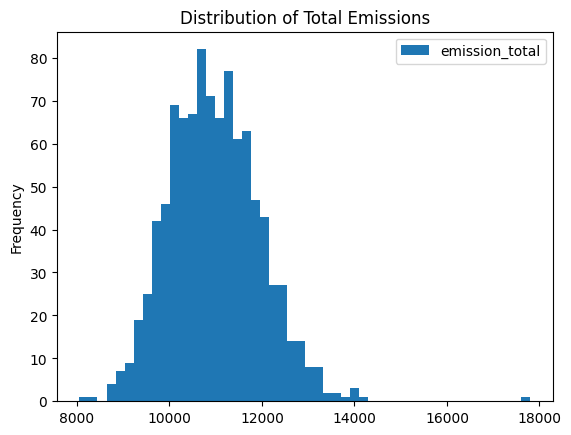

In [33]:
# Check distribution of emission_total
la_emission_df_sum_agg.plot(kind='hist', y='emission_total', bins=50, title='Distribution of Total Emissions')

In [34]:
# Print shape
print(la_emission_df_sum_agg.shape)
print(la_emission_df_sum_agg.primary_id.nunique())

(974, 2)
974


## Merge emissions df with lhs samples df

In [35]:
attr_primary_df = pd.read_csv(os.path.join(SIMULATION_DIR_PATH, "ATTRIBUTE_PRIMARY.csv"))
attr_primary_df

,primary_id,design_id,strategy_id,future_id
0,300300,4,0,0
1,370370,4,6004,0
2,370371,4,6004,1
3,370372,4,6004,2
4,370373,4,6004,3
...,...,...,...,...
997,371366,4,6004,996
998,371367,4,6004,997
999,371368,4,6004,998
1000,371369,4,6004,999


In [36]:
# Check for duplicates in primary_id
duplicates_primary = attr_primary_df[attr_primary_df.duplicated(subset=["primary_id"], keep=False)]
if not duplicates_primary.empty:
    print("Duplicated primary_id found:")
    print(duplicates_primary)
else:
    print("No duplicated primary_id found.")

No duplicated primary_id found.


In [37]:
#NOTE: We only care about strategy_id 6004 since it belongs to the ensemble experiment
attr_primary_df_filtered = attr_primary_df[attr_primary_df["strategy_id"] == 6004]
attr_primary_df_filtered

,primary_id,design_id,strategy_id,future_id
1,370370,4,6004,0
2,370371,4,6004,1
3,370372,4,6004,2
4,370373,4,6004,3
5,370374,4,6004,4
...,...,...,...,...
997,371366,4,6004,996
998,371367,4,6004,997
999,371368,4,6004,998
1000,371369,4,6004,999


In [38]:
# Check for duplicates in future_id in the filtered df
duplicates_future = attr_primary_df_filtered[attr_primary_df_filtered.duplicated(subset=["future_id"], keep=False)]
if not duplicates_future.empty:
    print("Duplicated future_id found:")
    print(duplicates_future)
else:
    print("No duplicated future_id found.")

No duplicated future_id found.


In [39]:
# Merge emissions df with the attribute primary df filtered
la_emission_df_w_future_id = la_emission_df_sum_agg.merge(attr_primary_df_filtered, on="primary_id", how="inner")

la_emission_df_w_future_id.head()

,primary_id,emission_total,design_id,strategy_id,future_id
0,370370,8056.489285,4,6004,0
1,370371,10674.108111,4,6004,1
2,370372,10968.158533,4,6004,2
3,370373,12106.291437,4,6004,3
4,370374,9998.878198,4,6004,4


In [40]:
# Check shape of the merged df
print(la_emission_df_sum_agg.shape)
print(la_emission_df_w_future_id.shape)

(974, 2)
(973, 5)


In [41]:
lhs_df_merged.head()

,design_id,future_id,60_X,61_X,62_X,63_X,64_X,65_X,66_X,67_X,...,1715_L,1716_L,1718_L,1730_L,1731_L,1734_L,1735_L,1737_L,1739_L,1740_L
0,-1,1,0.547746,0.784382,0.142538,0.798656,0.138570,0.461001,0.760845,0.677736,...,0.009016,0.593854,0.880245,0.309954,0.253500,0.406424,0.798275,0.452258,0.605287,0.026657
1,-1,2,0.104242,0.871744,0.885693,0.731615,0.393896,0.254986,0.388944,0.079108,...,0.934020,0.610388,0.658542,0.620146,0.150415,0.055407,0.995960,0.052648,0.893614,0.608447
2,-1,3,0.450676,0.745613,0.955297,0.108820,0.299103,0.962902,0.367651,0.181581,...,0.728165,0.798418,0.066505,0.718230,0.087879,0.123014,0.001255,0.693685,0.196415,0.197307
3,-1,4,0.793911,0.915802,0.259297,0.303791,0.188833,0.473412,0.973142,0.756275,...,0.638554,0.546941,0.238074,0.363871,0.374376,0.468245,0.705076,0.048635,0.847648,0.282021
4,-1,5,0.781801,0.126404,0.934463,0.344480,0.277149,0.441921,0.477712,0.973170,...,0.451593,0.602214,0.959041,0.671558,0.514413,0.191157,0.143267,0.914037,0.818161,0.733172


In [42]:
# Merge emissions data with lhs data
lhs_emissions_merged_df = pd.merge(lhs_df_merged, la_emission_df_w_future_id, on=["design_id", "future_id"], how="inner")
lhs_emissions_merged_df.head()

,design_id,future_id,60_X,61_X,62_X,63_X,64_X,65_X,66_X,67_X,...,1730_L,1731_L,1734_L,1735_L,1737_L,1739_L,1740_L,primary_id,emission_total,strategy_id
0,4,1,0.547746,0.784382,0.142538,0.798656,0.138570,0.461001,0.760845,0.677736,...,0.309954,0.253500,0.406424,0.798275,0.452258,0.605287,0.026657,370371,10674.108111,6004
1,4,2,0.104242,0.871744,0.885693,0.731615,0.393896,0.254986,0.388944,0.079108,...,0.620146,0.150415,0.055407,0.995960,0.052648,0.893614,0.608447,370372,10968.158533,6004
2,4,3,0.450676,0.745613,0.955297,0.108820,0.299103,0.962902,0.367651,0.181581,...,0.718230,0.087879,0.123014,0.001255,0.693685,0.196415,0.197307,370373,12106.291437,6004
3,4,4,0.793911,0.915802,0.259297,0.303791,0.188833,0.473412,0.973142,0.756275,...,0.363871,0.374376,0.468245,0.705076,0.048635,0.847648,0.282021,370374,9998.878198,6004
4,4,5,0.781801,0.126404,0.934463,0.344480,0.277149,0.441921,0.477712,0.973170,...,0.671558,0.514413,0.191157,0.143267,0.914037,0.818161,0.733172,370375,13064.774319,6004


In [43]:
print(lhs_df_merged.shape)
print(la_emission_df_w_future_id.shape)
print(lhs_emissions_merged_df.shape)

(2000, 92)
(973, 5)
(972, 95)


In [44]:
# rearrange columns to have future_id and primary_id at the front
cols_order = ["future_id", "primary_id"] + [col for col in lhs_emissions_merged_df.columns if col not in ["future_id", "primary_id"]]
lhs_emissions_merged_df = lhs_emissions_merged_df[cols_order]
lhs_emissions_merged_df

,future_id,primary_id,design_id,60_X,61_X,62_X,63_X,64_X,65_X,66_X,...,1718_L,1730_L,1731_L,1734_L,1735_L,1737_L,1739_L,1740_L,emission_total,strategy_id
0,1,370371,4,0.547746,0.784382,0.142538,0.798656,0.138570,0.461001,0.760845,...,0.880245,0.309954,0.253500,0.406424,0.798275,0.452258,0.605287,0.026657,10674.108111,6004
1,2,370372,4,0.104242,0.871744,0.885693,0.731615,0.393896,0.254986,0.388944,...,0.658542,0.620146,0.150415,0.055407,0.995960,0.052648,0.893614,0.608447,10968.158533,6004
2,3,370373,4,0.450676,0.745613,0.955297,0.108820,0.299103,0.962902,0.367651,...,0.066505,0.718230,0.087879,0.123014,0.001255,0.693685,0.196415,0.197307,12106.291437,6004
3,4,370374,4,0.793911,0.915802,0.259297,0.303791,0.188833,0.473412,0.973142,...,0.238074,0.363871,0.374376,0.468245,0.705076,0.048635,0.847648,0.282021,9998.878198,6004
4,5,370375,4,0.781801,0.126404,0.934463,0.344480,0.277149,0.441921,0.477712,...,0.959041,0.671558,0.514413,0.191157,0.143267,0.914037,0.818161,0.733172,13064.774319,6004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
967,996,371366,4,0.059039,0.417728,0.091020,0.318165,0.645634,0.513777,0.574314,...,0.595461,0.933921,0.174229,0.072819,0.103792,0.828721,0.216749,0.410230,10130.127022,6004
968,997,371367,4,0.461471,0.491210,0.210822,0.844321,0.633153,0.599206,0.763054,...,0.969377,0.913786,0.131970,0.825830,0.885375,0.885499,0.953261,0.107684,10146.023964,6004
969,998,371368,4,0.723537,0.180950,0.551961,0.158086,0.882026,0.818294,0.505303,...,0.151967,0.016360,0.844441,0.280939,0.762432,0.694464,0.093806,0.037454,11449.212896,6004
970,999,371369,4,0.479683,0.722598,0.275481,0.613768,0.764342,0.850816,0.851390,...,0.473299,0.953830,0.288994,0.656732,0.248549,0.055883,0.878139,0.122995,11229.198356,6004


In [45]:
# Drop some unnecessary columns
lhs_emissions_merged_df = lhs_emissions_merged_df.drop(columns=["design_id",
                                                                "strategy_id"])

In [46]:
# Check for nans
lhs_emissions_merged_df.isna().sum().sum()

np.int64(0)

## Filter out irrelevant lhs groups

In [47]:
var_traj_X_df = pd.read_csv(os.path.join(SIMULATION_DIR_PATH, "VARIABLE_TRAJECTORY_GROUPS_X.csv"))
var_traj_L_df = pd.read_csv(os.path.join(SIMULATION_DIR_PATH, "VARIABLE_TRAJECTORY_GROUPS_L.csv"))

In [48]:
# add suffix to items in variable_trajectory_group field items
var_traj_X_df["variable_trajectory_group_w_suffix"] = var_traj_X_df["variable_trajectory_group"].astype(str) + '_X'
var_traj_X_df.tail()

,variable,variable_trajectory_group,variable_trajectory_group_w_suffix
54,elasticity_scoe_enerdem_per_hh_residential_ele...,66,66_X
55,elasticity_scoe_enerdem_per_hh_residential_hea...,66,66_X
56,elasticity_trde_mtkm_to_gdp_freight,67,67_X
57,elasticity_trde_pkm_to_gdppc_private_and_public,68,68_X
58,elasticity_trde_pkm_to_gdppc_regional,68,68_X


In [49]:
# add suffix to items in variable_trajectory_group field items
var_traj_L_df["variable_trajectory_group_w_suffix"] = var_traj_L_df["variable_trajectory_group"].astype(str) + '_L'
var_traj_L_df.tail()

,transformation_code,variable,variable_field,variable_trajectory_group,variable_trajectory_group_w_suffix
554,TX:WASO:INC_RECYCLING_STRATEGY_NZ,Fraction of Waste Recycled,frac_waso_recycled_paper,59,59_L
555,TX:WASO:INC_RECYCLING_STRATEGY_NZ,Fraction of Waste Recycled,frac_waso_recycled_plastic,59,59_L
556,TX:WASO:INC_RECYCLING_STRATEGY_NZ,Fraction of Waste Recycled,frac_waso_recycled_rubber_leather,59,59_L
557,TX:WASO:INC_RECYCLING_STRATEGY_NZ,Fraction of Waste Recycled,frac_waso_recycled_textiles,59,59_L
558,TX:WASO:INC_RECYCLING_STRATEGY_NZ,Fraction of Waste Recycled,frac_waso_recycled_wood,59,59_L


In [50]:
var_traj_groups_X = var_traj_X_df["variable_trajectory_group_w_suffix"].unique()
var_traj_groups_L = var_traj_L_df["variable_trajectory_group_w_suffix"].unique()
print("Variable trajectory groups X:", var_traj_groups_X)
print("Variable trajectory groups L:", var_traj_groups_L)

Variable trajectory groups X: ['60_X' '61_X' '62_X' '63_X' '64_X' '65_X' '66_X' '67_X' '68_X']
Variable trajectory groups L: ['1_L' '2_L' '3_L' '4_L' '5_L' '6_L' '7_L' '8_L' '9_L' '10_L' '11_L'
 '12_L' '13_L' '14_L' '15_L' '16_L' '17_L' '18_L' '19_L' '20_L' '21_L'
 '22_L' '23_L' '24_L' '25_L' '26_L' '27_L' '28_L' '29_L' '30_L' '31_L'
 '32_L' '33_L' '34_L' '35_L' '36_L' '37_L' '38_L' '39_L' '40_L' '41_L'
 '42_L' '43_L' '44_L' '45_L' '46_L' '47_L' '48_L' '49_L' '50_L' '51_L'
 '52_L' '53_L' '54_L' '55_L' '56_L' '57_L' '58_L' '59_L']


In [51]:
# join the var_traj_groups
var_traj_groups_all = var_traj_groups_X.tolist() + var_traj_groups_L.tolist()
var_traj_groups_all = list(set(var_traj_groups_all))  # remove duplicates
print("All variable trajectory groups:", var_traj_groups_all)

All variable trajectory groups: ['9_L', '10_L', '24_L', '44_L', '45_L', '30_L', '28_L', '33_L', '15_L', '11_L', '13_L', '29_L', '58_L', '42_L', '8_L', '41_L', '47_L', '19_L', '52_L', '12_L', '62_X', '21_L', '1_L', '16_L', '53_L', '2_L', '38_L', '49_L', '48_L', '54_L', '65_X', '6_L', '60_X', '34_L', '67_X', '4_L', '46_L', '50_L', '25_L', '32_L', '7_L', '57_L', '66_X', '56_L', '68_X', '14_L', '20_L', '39_L', '17_L', '22_L', '26_L', '27_L', '63_X', '3_L', '64_X', '31_L', '36_L', '5_L', '61_X', '40_L', '18_L', '55_L', '35_L', '43_L', '23_L', '37_L', '51_L', '59_L']


In [52]:
df_cols = lhs_emissions_merged_df.columns.tolist()

# Filter the relevant_lhs_cols to only include those that are in df_cols
relevant_lhs_cols = [col for col in var_traj_groups_all if col in df_cols]

In [53]:
# filter to keep only relevant columns
cols_to_keep = ["future_id", "primary_id"] + list(relevant_lhs_cols) + ["emission_total"]
merged_df_filtered = lhs_emissions_merged_df[cols_to_keep]

In [54]:
print("Original merged DataFrame shape:", lhs_emissions_merged_df.shape)
print("Filtered merged DataFrame shape:", merged_df_filtered.shape)

Original merged DataFrame shape: (972, 93)
Filtered merged DataFrame shape: (972, 71)


In [55]:
print("Filtered merged DataFrame fields:", merged_df_filtered.columns.tolist())
print("Relevant LHS columns:", relevant_lhs_cols)

Filtered merged DataFrame fields: ['future_id', 'primary_id', '9_L', '10_L', '24_L', '44_L', '45_L', '30_L', '28_L', '33_L', '15_L', '11_L', '13_L', '29_L', '58_L', '42_L', '8_L', '41_L', '47_L', '19_L', '52_L', '12_L', '62_X', '21_L', '1_L', '16_L', '53_L', '2_L', '38_L', '49_L', '48_L', '54_L', '65_X', '6_L', '60_X', '34_L', '67_X', '4_L', '46_L', '50_L', '25_L', '32_L', '7_L', '57_L', '66_X', '56_L', '68_X', '14_L', '20_L', '39_L', '17_L', '22_L', '26_L', '27_L', '63_X', '3_L', '64_X', '31_L', '36_L', '5_L', '61_X', '40_L', '18_L', '55_L', '35_L', '43_L', '23_L', '37_L', '51_L', '59_L', 'emission_total']
Relevant LHS columns: ['9_L', '10_L', '24_L', '44_L', '45_L', '30_L', '28_L', '33_L', '15_L', '11_L', '13_L', '29_L', '58_L', '42_L', '8_L', '41_L', '47_L', '19_L', '52_L', '12_L', '62_X', '21_L', '1_L', '16_L', '53_L', '2_L', '38_L', '49_L', '48_L', '54_L', '65_X', '6_L', '60_X', '34_L', '67_X', '4_L', '46_L', '50_L', '25_L', '32_L', '7_L', '57_L', '66_X', '56_L', '68_X', '14_L', '

In [56]:
print([col for col in lhs_emissions_merged_df.columns if 'X' in col])
print([col for col in merged_df_filtered.columns if 'X' in col])

['60_X', '61_X', '62_X', '63_X', '64_X', '65_X', '66_X', '67_X', '68_X']
['62_X', '65_X', '60_X', '67_X', '66_X', '68_X', '63_X', '64_X', '61_X']


In [57]:
print([col for col in lhs_emissions_merged_df.columns if 'L' in col])
print([col for col in merged_df_filtered.columns if 'L' in col])

['1_L', '2_L', '3_L', '4_L', '5_L', '6_L', '7_L', '8_L', '9_L', '10_L', '11_L', '12_L', '13_L', '14_L', '15_L', '16_L', '17_L', '18_L', '19_L', '20_L', '21_L', '22_L', '23_L', '24_L', '25_L', '26_L', '27_L', '28_L', '29_L', '30_L', '31_L', '32_L', '33_L', '34_L', '35_L', '36_L', '37_L', '38_L', '39_L', '40_L', '41_L', '42_L', '43_L', '44_L', '45_L', '46_L', '47_L', '48_L', '49_L', '50_L', '51_L', '52_L', '53_L', '54_L', '55_L', '56_L', '57_L', '58_L', '59_L', '80_L', '1137_L', '1144_L', '1147_L', '1669_L', '1670_L', '1673_L', '1676_L', '1679_L', '1708_L', '1712_L', '1713_L', '1715_L', '1716_L', '1718_L', '1730_L', '1731_L', '1734_L', '1735_L', '1737_L', '1739_L', '1740_L']
['9_L', '10_L', '24_L', '44_L', '45_L', '30_L', '28_L', '33_L', '15_L', '11_L', '13_L', '29_L', '58_L', '42_L', '8_L', '41_L', '47_L', '19_L', '52_L', '12_L', '21_L', '1_L', '16_L', '53_L', '2_L', '38_L', '49_L', '48_L', '54_L', '6_L', '34_L', '4_L', '46_L', '50_L', '25_L', '32_L', '7_L', '57_L', '56_L', '14_L', '20_

In [58]:
merged_df_filtered.head()

,future_id,primary_id,9_L,10_L,24_L,44_L,45_L,30_L,28_L,33_L,...,40_L,18_L,55_L,35_L,43_L,23_L,37_L,51_L,59_L,emission_total
0,1,370371,0.373986,0.024119,0.538583,0.345412,0.055164,0.927934,0.257369,0.274968,...,0.564638,0.680266,0.678094,0.967606,0.643369,0.255837,0.604219,0.426574,0.912996,10674.108111
1,2,370372,0.896463,0.074430,0.632658,0.590931,0.099609,0.422740,0.592655,0.176500,...,0.726734,0.902547,0.316747,0.673351,0.705113,0.710315,0.044720,0.158652,0.934239,10968.158533
2,3,370373,0.698922,0.595067,0.973150,0.874385,0.341202,0.716014,0.853154,0.118951,...,0.536400,0.589297,0.082951,0.410823,0.609188,0.600763,0.989835,0.205757,0.945656,12106.291437
3,4,370374,0.113597,0.948863,0.778128,0.077945,0.617341,0.473497,0.942894,0.580326,...,0.237717,0.203194,0.497596,0.774451,0.597047,0.244681,0.902745,0.070456,0.966384,9998.878198
4,5,370375,0.628671,0.190891,0.057006,0.366491,0.350599,0.072427,0.157005,0.804465,...,0.542677,0.810124,0.130924,0.409055,0.168156,0.913753,0.030365,0.980789,0.911871,13064.774319


In [59]:
merged_df_filtered.columns

Index(['future_id', 'primary_id', '9_L', '10_L', '24_L', '44_L', '45_L',
       '30_L', '28_L', '33_L', '15_L', '11_L', '13_L', '29_L', '58_L', '42_L',
       '8_L', '41_L', '47_L', '19_L', '52_L', '12_L', '62_X', '21_L', '1_L',
       '16_L', '53_L', '2_L', '38_L', '49_L', '48_L', '54_L', '65_X', '6_L',
       '60_X', '34_L', '67_X', '4_L', '46_L', '50_L', '25_L', '32_L', '7_L',
       '57_L', '66_X', '56_L', '68_X', '14_L', '20_L', '39_L', '17_L', '22_L',
       '26_L', '27_L', '63_X', '3_L', '64_X', '31_L', '36_L', '5_L', '61_X',
       '40_L', '18_L', '55_L', '35_L', '43_L', '23_L', '37_L', '51_L', '59_L',
       'emission_total'],
      dtype='object')

## Add variable names to lhs columns

In [60]:
var_traj_L_df.tail()

,transformation_code,variable,variable_field,variable_trajectory_group,variable_trajectory_group_w_suffix
554,TX:WASO:INC_RECYCLING_STRATEGY_NZ,Fraction of Waste Recycled,frac_waso_recycled_paper,59,59_L
555,TX:WASO:INC_RECYCLING_STRATEGY_NZ,Fraction of Waste Recycled,frac_waso_recycled_plastic,59,59_L
556,TX:WASO:INC_RECYCLING_STRATEGY_NZ,Fraction of Waste Recycled,frac_waso_recycled_rubber_leather,59,59_L
557,TX:WASO:INC_RECYCLING_STRATEGY_NZ,Fraction of Waste Recycled,frac_waso_recycled_textiles,59,59_L
558,TX:WASO:INC_RECYCLING_STRATEGY_NZ,Fraction of Waste Recycled,frac_waso_recycled_wood,59,59_L


In [61]:
var_traj_X_df.tail()

,variable,variable_trajectory_group,variable_trajectory_group_w_suffix
54,elasticity_scoe_enerdem_per_hh_residential_ele...,66,66_X
55,elasticity_scoe_enerdem_per_hh_residential_hea...,66,66_X
56,elasticity_trde_mtkm_to_gdp_freight,67,67_X
57,elasticity_trde_pkm_to_gdppc_private_and_public,68,68_X
58,elasticity_trde_pkm_to_gdppc_regional,68,68_X


In [62]:
subset_cols = ["variable", "variable_trajectory_group_w_suffix"]
var_traj_all_df = pd.concat([var_traj_X_df[subset_cols], var_traj_L_df[subset_cols]], ignore_index=True)
var_traj_all_df

,variable,variable_trajectory_group_w_suffix
0,exports_agrc_bevs_and_spices_tonne,60_X
1,exports_agrc_cereals_tonne,60_X
2,exports_agrc_fibers_tonne,60_X
3,exports_agrc_fruits_tonne,60_X
4,exports_agrc_herbs_and_other_perennial_crops_t...,60_X
...,...,...
613,Fraction of Waste Recycled,59_L
614,Fraction of Waste Recycled,59_L
615,Fraction of Waste Recycled,59_L
616,Fraction of Waste Recycled,59_L


In [63]:
# drop duplicates if any
print("Before dropping duplicates, var_traj_all_df shape:", var_traj_all_df.shape)
var_traj_all_df = var_traj_all_df.drop_duplicates(subset=subset_cols)
print("After dropping duplicates, var_traj_all_df shape:", var_traj_all_df.shape)

Before dropping duplicates, var_traj_all_df shape: (618, 2)
After dropping duplicates, var_traj_all_df shape: (181, 2)


In [64]:
# check if there are any duplicated variable names
duplicated_vars = var_traj_all_df["variable"].duplicated().any()
if duplicated_vars:
    print("There are duplicated variable names in var_traj_all_df.")
else:
    print("No duplicated variable names in var_traj_all_df.")

There are duplicated variable names in var_traj_all_df.


In [65]:
# Filter var_traj_all_df by sample_group in relevant_lhs_cols
print("Before filtering by relevant_lhs_cols, var_traj_all_df shape:", var_traj_all_df.shape)
var_traj_all_df = var_traj_all_df[var_traj_all_df["variable_trajectory_group_w_suffix"].isin(relevant_lhs_cols)]
var_traj_all_df = var_traj_all_df.sort_values(by="variable_trajectory_group_w_suffix", ascending=True)
print("After filtering by relevant_lhs_cols, var_traj_all_df shape:", var_traj_all_df.shape)

Before filtering by relevant_lhs_cols, var_traj_all_df shape: (181, 2)
After filtering by relevant_lhs_cols, var_traj_all_df shape: (181, 2)


In [66]:
def process_variable_prefix(df, var_col='variable', group_col='variable_trajectory_group_w_suffix'):
    result = []
    for group, group_df in df.groupby(group_col):
        variables = group_df[var_col].tolist()
        if len(variables) == 1:
            prefix = variables[0]
        else:
            prefix = os.path.commonprefix(variables)
            # Clean trailing underscores
            prefix = prefix.rstrip('_')
            
        prefix = f"group_{group}_{prefix}"
        result.append({'variable_trajectory_group_w_suffix': group, 'variable_prefix': prefix})
    return pd.DataFrame(result)

prefix_df = process_variable_prefix(var_traj_all_df)
prefix_df

,variable_trajectory_group_w_suffix,variable_prefix
0,10_L,group_10_L_Fraction Non-Fugitive :math:\text{C...
1,11_L,group_11_L_Forest Sequestration Emission Factor
2,12_L,group_12_L_Average Industrial Energy Fuel Effi...
3,13_L,group_13_L_Industrial Energy Demand Scalar
4,14_L,group_14_L_Industrial Energy Fuel Fraction
...,...,...
63,68_X,group_68_X_elasticity_trde_pkm_to_gdppc
64,6_L,group_6_L_Electrical Transmission Loss Fraction
65,7_L,group_7_L_NemoMod MinShareProduction
66,8_L,group_8_L_NemoMod


In [67]:
# Check for duplicates in variable_trajectory_group_w_suffix and variable_prefix
dups = prefix_df.duplicated(subset=["variable_trajectory_group_w_suffix", "variable_prefix"], keep=False)
if dups.any():
    print("Duplicated variable_trajectory_group_w_suffix and variable_prefix found:")
    print(prefix_df[dups])
else:
    print("No duplicated variable_trajectory_group_w_suffix and variable_prefix found.")

# Check for duplicates in variable_trajectory_group_w_suffix
dups_group = prefix_df.duplicated(subset=["variable_trajectory_group_w_suffix"], keep=False)
if dups_group.any():
    print("Duplicated variable_trajectory_group_w_suffix found:")
    print(prefix_df[dups_group])
else:
    print("No duplicated variable_trajectory_group_w_suffix found.")

# Check for duplicates in variable_prefix
dups_prefix = prefix_df.duplicated(subset=["variable_prefix"], keep=False)
if dups_prefix.any():
    print("Duplicated variable_prefix found:")
    print(prefix_df[dups_prefix])
else:
    print("No duplicated variable_prefix found.")

No duplicated variable_trajectory_group_w_suffix and variable_prefix found.
No duplicated variable_trajectory_group_w_suffix found.
No duplicated variable_prefix found.


In [68]:
# var_traj_all_df[var_traj_all_df["variable_trajectory_group"].isin([3, 13, 40])]

In [69]:
# prefix_df.loc[prefix_df["sample_group"] == 13, "variable_prefix"] = "group_13_frac_gnrl_eating_red_meats+"
# prefix_df.loc[prefix_df["sample_group"] == 40, "variable_prefix"] = "group_40_pij_lndu_grasslands+"

# prefix_df = prefix_df.sort_values(by="variable_prefix", ascending=True)
# prefix_df

In [70]:
# Let's use the prefix_df to rename the columns in merged_df_filtered
def rename_columns_with_prefix(merged_df, prefix_df):
    df = merged_df.copy()
    # Create a mapping from str(group) to prefix
    group_to_prefix = {str(row['variable_trajectory_group_w_suffix']): row['variable_prefix'] for _, row in prefix_df.iterrows()}
    # Only rename columns that match a group
    rename_dict = {col: group_to_prefix[col] for col in df.columns if col in group_to_prefix}
    df = df.rename(columns=rename_dict)
    return df

merged_df_filtered_w_prefix = rename_columns_with_prefix(merged_df_filtered, prefix_df)

In [71]:
merged_df_filtered_w_prefix

,future_id,primary_id,group_9_L_,group_10_L_Fraction Non-Fugitive :math:\text{CH}_4 Flared,group_24_L_Livestock Manure Management Fraction,group_44_L_Transportation Mode Fuel Fraction,group_45_L_Freight Transportation Mode Share,group_30_L_Industrial :math:\text{CO}_2 Capture Prevalence,group_28_L_Carrying Capacity Scalar,group_33_L_SCOE Efficiency Factor for Heat Energy from Solid Biomass,...,group_40_L_Average Passenger Vehicle Occupancy Rate,group_18_L_PFC-,group_55_L_Fraction of Landfill Gas Recovered at Landfills,group_35_L_Liming Demand Scalar,group_43_L_Transportation Mode Fuel Fraction,group_23_L_Biogas Recovery Factor at LSMM Anaerobic Facilities,group_37_L_Transportation Demand Scalar,group_51_L_Treatment Fraction,group_59_L_Fraction of Waste Recycled,emission_total
0,1,370371,0.373986,0.024119,0.538583,0.345412,0.055164,0.927934,0.257369,0.274968,...,0.564638,0.680266,0.678094,0.967606,0.643369,0.255837,0.604219,0.426574,0.912996,10674.108111
1,2,370372,0.896463,0.074430,0.632658,0.590931,0.099609,0.422740,0.592655,0.176500,...,0.726734,0.902547,0.316747,0.673351,0.705113,0.710315,0.044720,0.158652,0.934239,10968.158533
2,3,370373,0.698922,0.595067,0.973150,0.874385,0.341202,0.716014,0.853154,0.118951,...,0.536400,0.589297,0.082951,0.410823,0.609188,0.600763,0.989835,0.205757,0.945656,12106.291437
3,4,370374,0.113597,0.948863,0.778128,0.077945,0.617341,0.473497,0.942894,0.580326,...,0.237717,0.203194,0.497596,0.774451,0.597047,0.244681,0.902745,0.070456,0.966384,9998.878198
4,5,370375,0.628671,0.190891,0.057006,0.366491,0.350599,0.072427,0.157005,0.804465,...,0.542677,0.810124,0.130924,0.409055,0.168156,0.913753,0.030365,0.980789,0.911871,13064.774319
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
967,996,371366,0.404157,0.553280,0.069172,0.762041,0.626293,0.156896,0.973378,0.713485,...,0.436091,0.879448,0.454406,0.440905,0.183589,0.754440,0.268893,0.804961,0.624680,10130.127022
968,997,371367,0.023762,0.656320,0.115575,0.683166,0.070693,0.583812,0.107913,0.678148,...,0.228810,0.481454,0.380648,0.592632,0.400222,0.330972,0.406130,0.320676,0.592311,10146.023964
969,998,371368,0.421406,0.726682,0.011981,0.399097,0.115417,0.020988,0.743230,0.631908,...,0.652671,0.710413,0.230669,0.288940,0.937345,0.956762,0.117653,0.182909,0.212273,11449.212896
970,999,371369,0.269400,0.330370,0.758967,0.577280,0.703997,0.717629,0.169666,0.857647,...,0.843376,0.528783,0.247991,0.698465,0.445180,0.465993,0.576015,0.269783,0.761636,11229.198356


In [72]:
print(merged_df_filtered.shape)
print(merged_df_filtered_w_prefix.shape)

(972, 71)
(972, 71)


In [73]:
# check for duplicated column names
duplicated_cols = merged_df_filtered_w_prefix.columns[merged_df_filtered_w_prefix.columns.duplicated()].tolist()
if duplicated_cols:
    print("Duplicated column names found:", duplicated_cols)
else:
    print("No duplicated column names found.")

No duplicated column names found.


## Finally we save the processed data as training data

In [74]:
# Create training directory if it doesn't exist
os.makedirs(TRAINING_DIR_PATH, exist_ok=True)

In [75]:
#save the merged DataFrame to a CSV file
merged_df_filtered_w_prefix.to_csv(os.path.join(TRAINING_DIR_PATH, "training_data_w_suffix.csv"), index=False)

In [76]:
# save the version without suffix for backward compatibility
merged_df_filtered.to_csv(os.path.join(TRAINING_DIR_PATH, "training_data.csv"), index=False)